# Assignment and count statistic

Statistic for assignment and counts of the MPRA experiment.

## General code

libraries and scripts

In [11]:
R.version

               _                           
platform       x86_64-conda-linux-gnu      
arch           x86_64                      
os             linux-gnu                   
system         x86_64, linux-gnu           
status                                     
major          4                           
minor          3.3                         
year           2024                        
month          02                          
day            29                          
svn rev        86002                       
language       R                           
version.string R version 4.3.3 (2024-02-29)
nickname       Angel Food Cake             

In [13]:
install.packages("tidyverse")

also installing the dependencies ‘colorspace’, ‘sys’, ‘bit’, ‘ps’, ‘sass’, ‘cachem’, ‘farver’, ‘munsell’, ‘rappdirs’, ‘askpass’, ‘bit64’, ‘processx’, ‘highr’, ‘xfun’, ‘yaml’, ‘bslib’, ‘tinytex’, ‘backports’, ‘memoise’, ‘data.table’, ‘isoband’, ‘scales’, ‘gargle’, ‘cellranger’, ‘curl’, ‘ids’, ‘rematch2’, ‘mime’, ‘openssl’, ‘timechange’, ‘systemfonts’, ‘textshaping’, ‘vroom’, ‘tzdb’, ‘callr’, ‘fs’, ‘knitr’, ‘rmarkdown’, ‘selectr’, ‘stringi’, ‘broom’, ‘conflicted’, ‘dbplyr’, ‘dplyr’, ‘dtplyr’, ‘forcats’, ‘ggplot2’, ‘googledrive’, ‘googlesheets4’, ‘haven’, ‘httr’, ‘lubridate’, ‘magrittr’, ‘modelr’, ‘purrr’, ‘ragg’, ‘readr’, ‘readxl’, ‘reprex’, ‘rvest’, ‘stringr’, ‘tibble’, ‘tidyr’, ‘xml2’


Warning message in install.packages("tidyverse"):
“installation of package ‘colorspace’ had non-zero exit status”
Warning message in install.packages("tidyverse"):
“installation of package ‘sys’ had non-zero exit status”
Warning message in install.packages("tidyverse"):
“installation of package ‘bit’ ha

In [59]:
library(tidyverse)
library(LSD)
# setwd("/fast/groups/ag_kircher/work/MPRA/ProximalPromoter/projects/experiment_statistic")

In [17]:
standard_style <- function() {
  ## styles
  size.text = 20;
  size.title = 25;
  size.line = 1;
  size.geom_line = 2;
  size.geom_point = 4
  standard_style <- theme_bw() + theme(plot.title = element_text(size = size.title, face="bold",hjust = 0.5),
                    panel.grid.major = element_blank() , panel.grid.minor = element_blank(), panel.border = element_blank(),
                    axis.text = element_text(colour = "black",size=size.text), axis.title = element_text(colour = "black",size=size.title), axis.ticks = element_line(colour = "black", size=1), axis.line.y = element_line(color="black", size = size.line), axis.line = element_line(colour = "black", size=size.line),
                    legend.key =  element_blank(), legend.text = element_text(size=size.text),
                    legend.direction="horizontal", legend.position = c("top"), legend.background = element_rect(fill = "transparent", colour = "transparent"), legend.margin = margin(0, 0, 0, 0),
                    legend.key.size = unit(2, 'lines'), legend.title=element_text(size=size.text))+
                    theme(axis.line.x = element_line(color="black", size = size.line))
}

## Assignment statistic

In [48]:
bcs <- read_delim(
    "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/assignment/standardAssignIGVFDesignNoTemp/assignment_barcodes.standardConfig.sorted.tsv.gz", 
    delim = "\t", escape_double = FALSE, col_names = c("BC", "Oligo", "XS", "Support_ratio"), col_select = c(1,2), trim_ws = TRUE
    )

Rows: 6305466 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): BC, Oligo

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [49]:
bcs <- bcs %>%
    group_by(Oligo) %>%
    count() %>% ungroup()



Warning message:
“Use of `bcs$n` is discouraged.
ℹ Use `n` instead.”
Warning message:
“Use of `bcs$n` is discouraged.
ℹ Use `n` instead.”
Warning message in geom_text(aes(y = 1000, label = sprintf("\n\nmean = %.2f", mean(bcs$n)), :
“All aesthetics have length 1, but the data has 75004 rows.
ℹ Did you mean to use `annotate()`?”
Warning message:
“Use of `bcs$n` is discouraged.
ℹ Use `n` instead.”
Warning message:
“Use of `bcs$n` is discouraged.
ℹ Use `n` instead.”
Warning message in geom_text(aes(y = 1000, label = sprintf("\nmedian = %.0f\n", :
“All aesthetics have length 1, but the data has 75004 rows.
ℹ Did you mean to use `annotate()`?”
Warning message:
“Removed 256 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


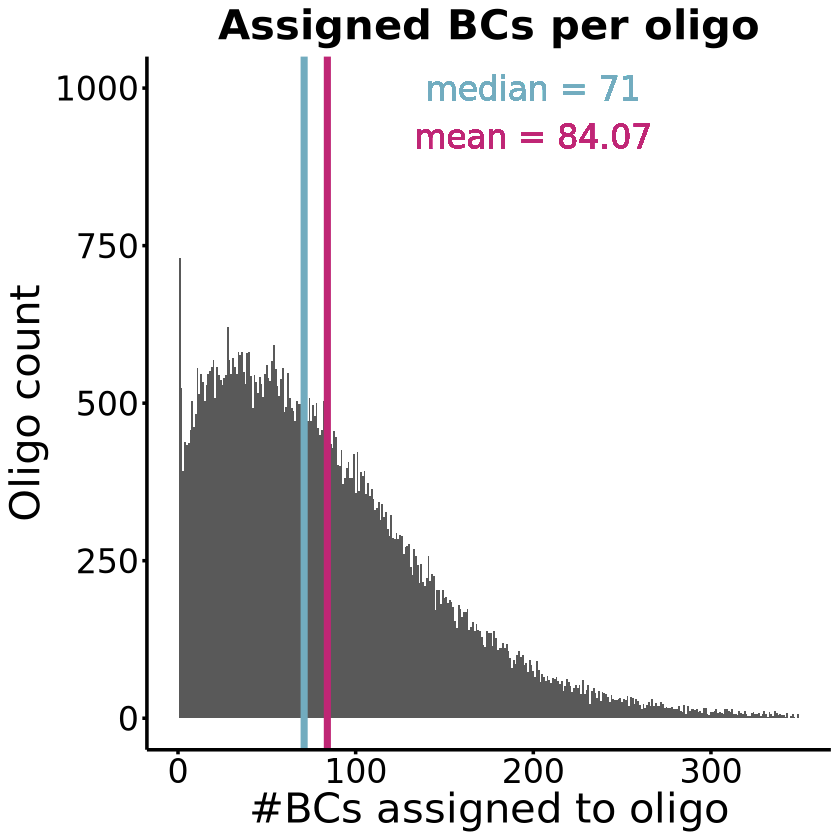

In [50]:
p <- ggplot(bcs, aes(n)) +
    geom_histogram(binwidth = 1) +
    xlim(0,350) +
    geom_vline(aes(xintercept = mean(bcs$n)), col = "#BF2675", linewidth = 2) +
    geom_text(aes(
        y = 1000, label = sprintf("\n\nmean = %.2f", mean(bcs$n)),
        x = 200
    ), colour = "#BF2675",size=7) +
    geom_vline(aes(xintercept = median(bcs$n)), col = "#72ACBF", linewidth = 2) +
    geom_text(aes(
        y = 1000, label = sprintf("\nmedian = %.0f\n", median(bcs$n)),
        x = 200
    ), colour = "#72ACBF",size=7) +
    labs(title = "Assigned BCs per oligo", x = "#BCs assigned to oligo", y = "Oligo count") +
    standard_style()

p
#ggsave(opt$plot, p, type="cairo", dpi=300)

In [9]:
ggsave("plots/assignment_histogram.png", p, type="cairo", dpi=300)
ggsave("plots/assignment_histogram.pdf", p, dpi=300)
ggsave("plots/assignment_histogram.svg", p, dpi=300)

Saving 6.67 x 6.67 in image
Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”
Warning message:
“Use of `bcs$n` is discouraged.
ℹ Use `n` instead.”
Warning message:
“Use of `bcs$n` is discouraged.
ℹ Use `n` instead.”
Warning message:
“Use of `bcs$n` is discouraged.
ℹ Use `n` instead.”
Warning message:
“Use of `bcs$n` is discouraged.
ℹ Use `n` instead.”
Warning message:
“Removed 328 rows containing non-finite values (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values (`geom_bar()`).”
Saving 6.67 x 6.67 in image
Warning message:
“Use of `bcs$n` is discouraged.
ℹ Use `n` instead.”
Warning message:
“Use of `bcs$n` is discouraged.
ℹ Use `n` instead.”
Warning message:
“Use of `bcs$n` is discouraged.
ℹ Use `n` instead.”
Warning message:
“Use of `bcs$n` is discouraged.
ℹ Use `n` instead.”
Warning message:
“Removed 328 rows containing non-finite values (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values (`ge

## Count statistic

### HepG2

In [52]:
bcs <- read_delim(
    "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_allreps_merged.tsv.gz", 
    delim = "\t", escape_double = FALSE, col_select = c("replicate","name","log2","n_obs_bc"), trim_ws = TRUE
    ) %>% filter(name != "no_BC")

Rows: 224013 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): name
dbl (3): replicate, log2, n_obs_bc

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [53]:
bcs %>% head()

replicate,name,log2,n_obs_bc
<dbl>,<chr>,<dbl>,<dbl>
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V_HNF4_Q6:AAGGTCCAG;155:V_HNF4_Q6:AAGGTCCAG,0.06216882,106
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V_HNF6_Q6:CAAAATCAATAA;155:V_HNF6_Q6:CAAAATCAATAA,1.22087619,99
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC;36:V_HNF3ALPHA_Q6:TGTTTGCTTTG;50:V_HNF6_Q6:CAAAATCAATAA;65:V_HNF4_Q6:AAGGTCCAG;77:V_PPARA_02:CCGGGTCATTGGGGTCAGG;99:V_XBP1_01:GTGATGACGTGTCCCAT;119:V_HNF1_C:AGTTAATGATTAACCAA;139:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC,0.18618021,68
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_HNF3ALPHA_Q6:TGTTTGCTTTG;24:V_HNF6_Q6:CAAAATCAATAA;39:V_Rxra_UP:GGCCGTGACCCCGTGAT;59:V_PPARA_02:CCGGGTCATTGGGGTCAGG;81:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC;103:V_HNF1_C:AGTTAATGATTAACCAA;123:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC;149:V_HNF4_Q6:AAGGTCCAG,0.28843703,89
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_HNF4_Q6:AAGGTCCAG;22:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC;44:V_PPARA_02:CCGGGTCATTGGGGTCAGG;66:V_HNF6_Q6:CAAAATCAATAA;81:V_HNF1_C:AGTTAATGATTAACCAA;101:V_HNF3ALPHA_Q6:TGTTTGCTTTG;115:V_XBP1_01:GTGATGACGTGTCCCAT;135:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC,0.02681551,54
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_XBP1_01:GTGATGACGTGTCCCAT;30:V_HNF4_Q6:AAGGTCCAG;42:V_HNF6_Q6:CAAAATCAATAA;57:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC;79:V_HNF3ALPHA_Q6:TGTTTGCTTTG;93:V_Rxra_UP:GGCCGTGACCCCGTGAT;113:V_PPARA_02:CCGGGTCATTGGGGTCAGG;135:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC,0.25722241,43


In [54]:
bcs_per_oligo = bcs %>%
    group_by(name) %>% summarise_at(vars(n_obs_bc), list(name = mean))
bcs_per_oligo %>% head()

name
<dbl>
108.33333
101.33333
67.33333
90.66667
54.66667
43.33333


Warning message in geom_text(aes(y = 800, label = sprintf("\n\nmean = %.2f", mean(name)), :
“All aesthetics have length 1, but the data has 74876 rows.
ℹ Did you mean to use `annotate()`?”
Warning message in geom_text(aes(y = 800, label = sprintf("\nmedian = %.0f\n", median(name)), :
“All aesthetics have length 1, but the data has 74876 rows.
ℹ Did you mean to use `annotate()`?”
Warning message:
“Removed 103 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


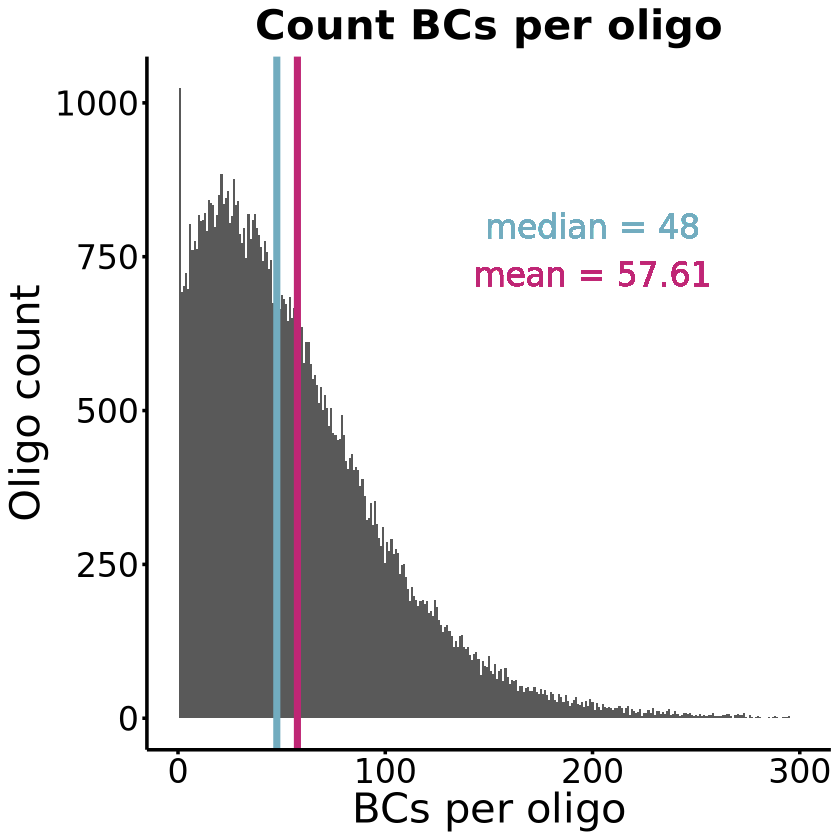

In [55]:
p <- ggplot(bcs_per_oligo, aes(name)) +
    geom_histogram(binwidth = 1) +
    xlim(0,300) +
    geom_vline(aes(xintercept = mean(name)), col = "#BF2675", linewidth = 2) +
    geom_text(aes(
        y = 800, label = sprintf("\n\nmean = %.2f", mean(name)),
        x = 200
    ), colour = "#BF2675",size=7) +
    geom_vline(aes(xintercept = median(name)), col = "#72ACBF", linewidth = 2) +
    geom_text(aes(
        y = 800, label = sprintf("\nmedian = %.0f\n", median(name)),
        x = 200
    ), colour = "#72ACBF",size=7) +
    labs(title = "Count BCs per oligo", x = "BCs per oligo", y = "Oligo count") +
    standard_style()

p

In [14]:
ggsave("plots/HepG2_count_histogram.png", p, type="cairo", dpi=300)
ggsave("plots/HepG2_count_histogram.pdf", p, dpi=300)
ggsave("plots/HepG2_count_histogram.svg", p, dpi=300)

Saving 6.67 x 6.67 in image
Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”
Warning message:
“Removed 223 rows containing non-finite values (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values (`geom_bar()`).”
Saving 6.67 x 6.67 in image
Warning message:
“Removed 223 rows containing non-finite values (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values (`geom_bar()`).”
Saving 6.67 x 6.67 in image
Warning message:
“Removed 223 rows containing non-finite values (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values (`geom_bar()`).”


In [61]:
bcs

replicate,name,log2,n_obs_bc
<dbl>,<chr>,<dbl>,<dbl>
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V_HNF4_Q6:AAGGTCCAG;155:V_HNF4_Q6:AAGGTCCAG,0.06216882,106
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V_HNF6_Q6:CAAAATCAATAA;155:V_HNF6_Q6:CAAAATCAATAA,1.22087619,99
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC;36:V_HNF3ALPHA_Q6:TGTTTGCTTTG;50:V_HNF6_Q6:CAAAATCAATAA;65:V_HNF4_Q6:AAGGTCCAG;77:V_PPARA_02:CCGGGTCATTGGGGTCAGG;99:V_XBP1_01:GTGATGACGTGTCCCAT;119:V_HNF1_C:AGTTAATGATTAACCAA;139:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC,0.18618021,68
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_HNF3ALPHA_Q6:TGTTTGCTTTG;24:V_HNF6_Q6:CAAAATCAATAA;39:V_Rxra_UP:GGCCGTGACCCCGTGAT;59:V_PPARA_02:CCGGGTCATTGGGGTCAGG;81:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC;103:V_HNF1_C:AGTTAATGATTAACCAA;123:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC;149:V_HNF4_Q6:AAGGTCCAG,0.28843703,89
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_HNF4_Q6:AAGGTCCAG;22:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC;44:V_PPARA_02:CCGGGTCATTGGGGTCAGG;66:V_HNF6_Q6:CAAAATCAATAA;81:V_HNF1_C:AGTTAATGATTAACCAA;101:V_HNF3ALPHA_Q6:TGTTTGCTTTG;115:V_XBP1_01:GTGATGACGTGTCCCAT;135:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC,0.02681551,54
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_XBP1_01:GTGATGACGTGTCCCAT;30:V_HNF4_Q6:AAGGTCCAG;42:V_HNF6_Q6:CAAAATCAATAA;57:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC;79:V_HNF3ALPHA_Q6:TGTTTGCTTTG;93:V_Rxra_UP:GGCCGTGACCCCGTGAT;113:V_PPARA_02:CCGGGTCATTGGGGTCAGG;135:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC,0.25722241,43
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_XBP1_01:GTGATGACGTGTCCCAT;30:V_HNF4_Q6:AAGGTCCAG;42:V_Rxra_UP:GGCCGTGACCCCGTGAT;62:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC;84:V_HNF3ALPHA_Q6:TGTTTGCTTTG;98:V_PPARA_02:CCGGGTCATTGGGGTCAGG;120:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC;146:V_HNF6_Q6:CAAAATCAATAA,0.25153877,45
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|113:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC,0.19639721,38
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|113:V_HNF1_C:AGTTAATGATTAACCAA,0.13927479,62


[1] "Pearson"
[1] 0.8691009
[1] "Spearman"
[1] 0.7714335
[1] "Pearson"
[1] 0.860811
[1] "Spearman"
[1] 0.7470312


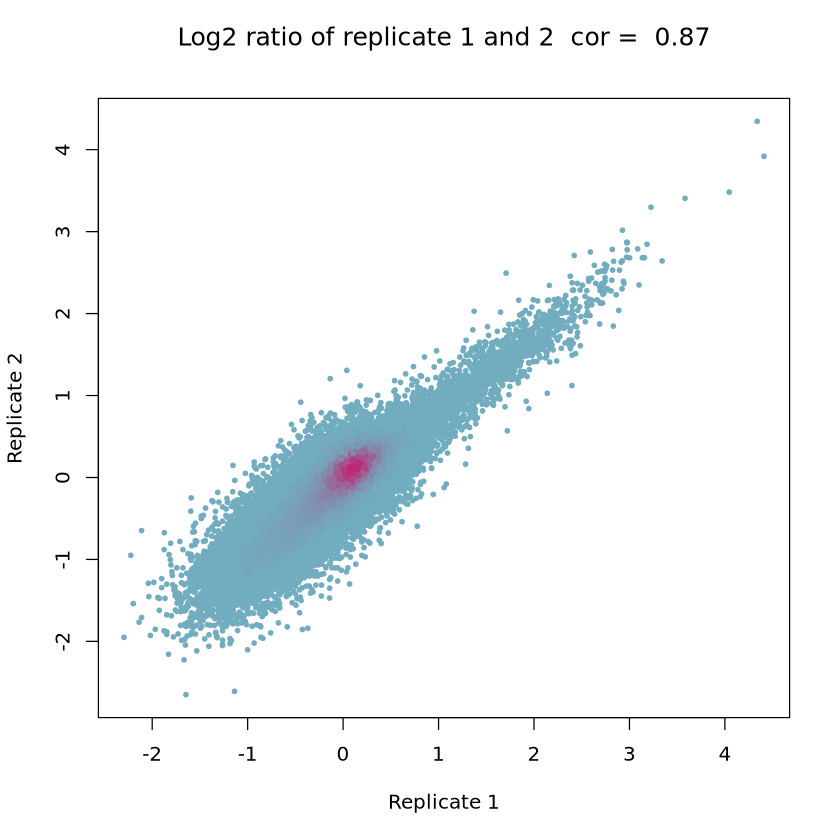

[1] "Pearson"
[1] 0.8404236
[1] "Spearman"
[1] 0.7374406


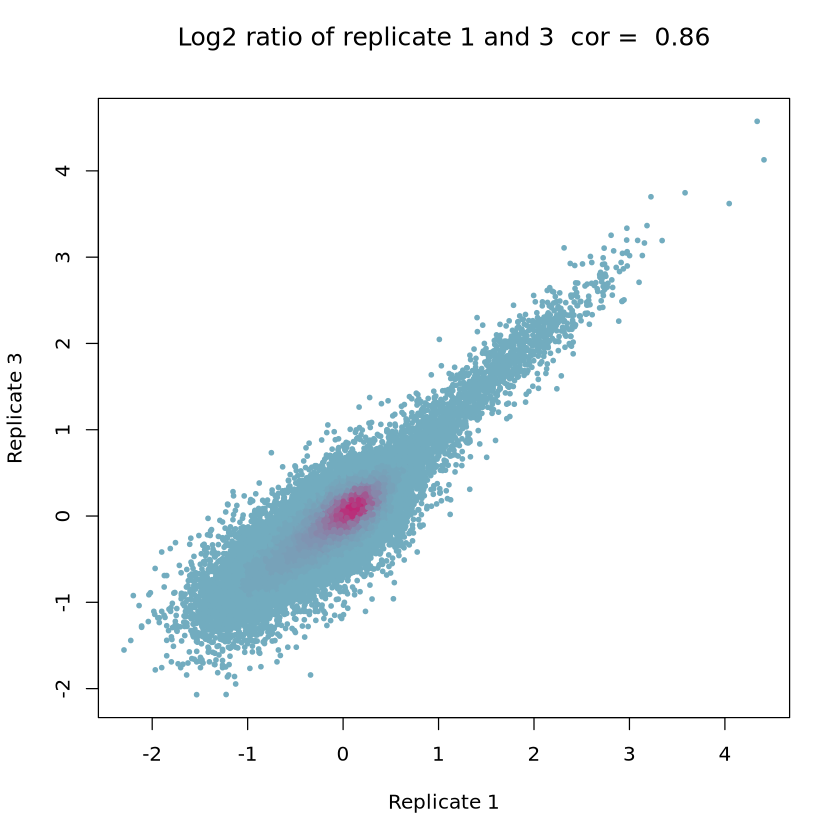

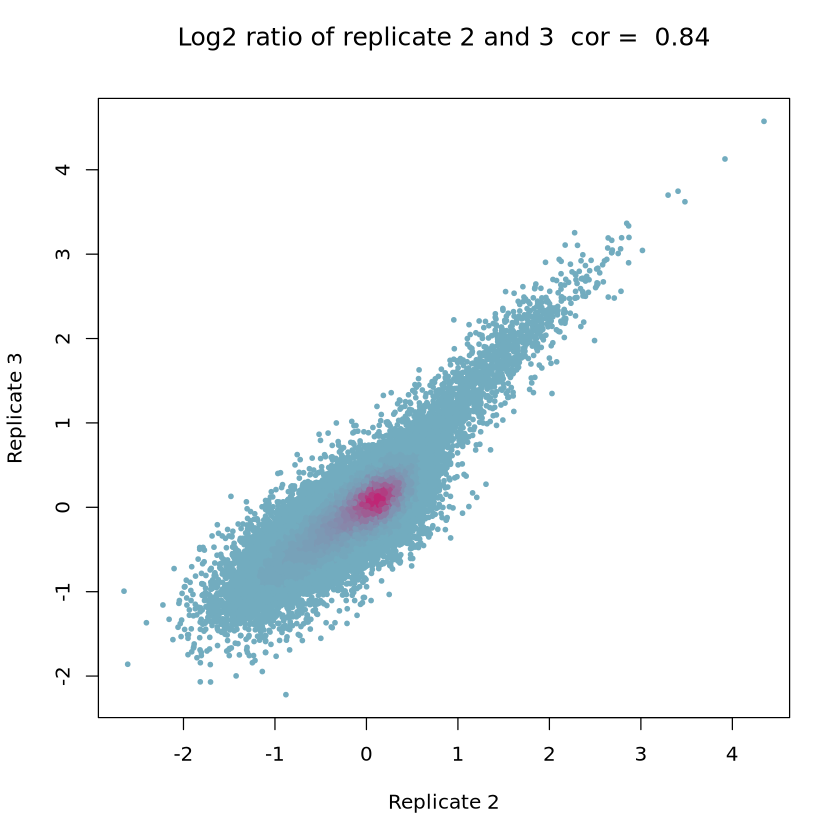

In [60]:
bcs <- bcs %>% filter(n_obs_bc >= 10)

correlate_replicates <- function(data, r1, r2) {
    data1 = data %>% filter(replicate == r1)
    data2 = data %>% filter(replicate == r2)
    res <- data1 %>% inner_join(data2, by = c("name"))

    print("Pearson")
    print(cor(res$log2.x, res$log2.y))
    print("Spearman")
    print(cor(res$log2.x, res$log2.y, method='spearman'))

    p <- heatscatter(res$log2.x, res$log2.y, 
        xlab=sprintf("Replicate %d", r1), 
        ylab=sprintf("Replicate %d", r2),
        cex=0.5,
        cor=TRUE,
        method="pearson",
        main=sprintf("Log2 ratio of replicate %d and %d", r1, r2),
        colpal=c( "#72ACBF", "#BF2675")
    )
    return(p)
}

p1 <- correlate_replicates(bcs, 1,2)
p2 <- correlate_replicates(bcs, 1,3)
p3 <- correlate_replicates(bcs, 2,3)



In [16]:
png("plots/HepG2_count_ratio_correlation.png", width=60, height=20, units="cm", res=300)
par(mfrow=c(1,3))
correlate_replicates(bcs, 1,2)
correlate_replicates(bcs, 1,3)
correlate_replicates(bcs, 2,3)
dev.off()

[1] "Pearson"
[1] 0.740364
[1] "Spearman"
[1] 0.6554085


NULL

[1] "Pearson"
[1] 0.7178295
[1] "Spearman"
[1] 0.6252296


NULL

[1] "Pearson"
[1] 0.7223191
[1] "Spearman"
[1] 0.6249686


NULL

png 
  2

In [17]:
pdf("plots/HepG2_count_ratio_correlation.pdf", width = 30, height = 10)
par(mfrow=c(1,3))
correlate_replicates(bcs, 1,2)
correlate_replicates(bcs, 1,3)
correlate_replicates(bcs, 2,3)
dev.off()


[1] "Pearson"
[1] 0.740364
[1] "Spearman"
[1] 0.6554085


NULL

[1] "Pearson"
[1] 0.7178295
[1] "Spearman"
[1] 0.6252296


NULL

[1] "Pearson"
[1] 0.7223191
[1] "Spearman"
[1] 0.6249686


NULL

png 
  2

In [18]:
svg("plots/HepG2_count_ratio_correlation_r1_r2.svg")
correlate_replicates(bcs, 1,2)
dev.off()
svg("plots/HepG2_count_ratio_correlation_r1_r3.svg")
correlate_replicates(bcs, 1,3)
dev.off()
svg("plots/HepG2_count_ratio_correlation_r2_r3.svg")
correlate_replicates(bcs, 2,3)
dev.off()

[1] "Pearson"
[1] 0.740364
[1] "Spearman"
[1] 0.6554085


NULL

png 
  2

[1] "Pearson"
[1] 0.7178295
[1] "Spearman"
[1] 0.6252296


NULL

png 
  2

[1] "Pearson"
[1] 0.7223191
[1] "Spearman"
[1] 0.6249686


NULL

png 
  2